# FAM visit telemetry — time history and distributions (v1)

**Author:** Aaron Roodman
**Created:** 2026-09-08 · **Last modified:** 2026-09-08
**Status:** current
**Keywords:** AOS, FAM, telemetry, EFD, ConsDB, Trim, LUT, thermal, wind

Survey of the per-visit telemetry attached to the combined Full Array Mode (FAM)
`visits.parquet`. For each logical group of telemetry one representative quantity is
plotted as a time history against `day_obs` and as a distribution, so that coverage gaps,
drifts and outliers are visible in one place.

**Output:** figures inline; optionally a PDF under `output/<param_set>/fam_processing/`.

**References**
- [`docs/telemetry.md`](../../docs/telemetry.md) — every quantity, its ConsDB or EFD name, coverage and units
- [`docs/studies/fam_processing.md`](../../docs/studies/fam_processing.md) — the study this belongs to
- Telemetry is attached by `code/fam_processing/run_attach_telemetry.py`


## Change Log

| date | change |
|---|---|
| 2026-09-08 | created |


## Table of Contents

1. [Parameters](#params)
2. [Setup](#setup)
3. [Helper functions](#functions)
4. [Load the combined visits table](#data)
5. [Coverage overview](#coverage)
6. [Thermal — M1M3 gradients](#thermal-grad)
7. [Thermal — air and structure temperatures](#thermal-air)
8. [Camera body temperatures](#camera)
9. [Wind and airflow](#wind)
10. [Commanded degrees of freedom — Trim and Tweak](#dof)
11. [Mirror look-up-table forces](#lut)
12. [Pointing and image quality](#pointing)

The M1M3 thermocouple family reads 0 columns here even though the 2026 per-chunk tables
carry 196 of them (146 `m1m3_tc_*` plus 50 `m1m3_dt_*`). `combine_parquets` unifies chunk
schemas as their **intersection**, and the five 2025 chunks do not have those columns, so
they do not survive into the combined table. The four `*_gradient` columns are derived from
the same thermocouples and are present throughout, which is what the analyses use.


<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================
PARAM_SET = 'fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x'

# Output root, relative to the topic directory (resolved in Setup). Set an absolute path
# to override, e.g. the /sdf/group form when the repo-relative symlink does not resolve.
OUTPUT_ROOT = 'output'

SAVE_PDF = False          # True -> also write fam_processing/telemetry_history.pdf
FIGSIZE = (13, 3.4)       # one row: time history + histogram
NBINS = 60                # histogram bins

<a id='setup'></a>
## 2. Setup

In [2]:
import sys
from pathlib import Path

# Walk up to the topic directory (the one holding code/), so this works at any depth.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from common.utils import alt_to_deg, nmad

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print(f'topic dir: {_TOPIC}')

topic dir: /sdf/home/r/roodman/notebooks/rubin-work/aos


<a id='functions'></a>
## 3. Helper functions

In [3]:
def show(col, unit, label=None, transform=None, clip_pct=None, ax_pair=None):
    """Time history against day_obs plus a distribution, for one telemetry column.

    Parameters
    ----------
    col : `str`
        Column name in the visits table.
    unit : `str`
        Physical unit of the quantity, printed on both axes and in the summary line.
    label : `str`, optional
        Display name; defaults to `col`.
    transform : `callable`, optional
        Applied to the raw values, e.g. `alt_to_deg` for altitude in radians.
    clip_pct : `float`, optional
        Percentile clip for the histogram x-range only, e.g. 99.5 to keep a few extreme
        outliers from flattening the distribution. The time history always shows everything.
    ax_pair : `tuple`, optional
        Existing (ax_time, ax_hist) to draw into instead of making a new figure.

    Returns
    -------
    stats : `dict`
        n_finite, median, nmad and the min/max, all in `unit`.
    """
    if col not in df.columns:
        print(f'{col}: ABSENT from this table')
        return None
    v = df[col].to_numpy(dtype=float, na_value=np.nan)
    if transform is not None:
        v = transform(v)
    good = np.isfinite(v)
    name = label or col
    if not good.any():
        print(f'{name}: 0 of {len(v)} finite -- nothing to plot')
        return None

    if ax_pair is None:
        fig, (a0, a1) = plt.subplots(1, 2, figsize=FIGSIZE,
                                     gridspec_kw={'width_ratios': [3, 1]})
    else:
        a0, a1 = ax_pair

    # Time history: plot against a contiguous index of sorted nights so that gaps between
    # observing campaigns do not stretch the axis, but label with the real day_obs.
    a0.plot(mjd[good], v[good], '.', ms=2.5, alpha=0.55)
    a0.set_xlabel('MJD')
    a0.set_ylabel(f'{name}\n({unit})')
    med, sig = float(np.median(v[good])), float(nmad(v[good]))
    a0.axhline(med, color='crimson', lw=1.0,
               label=f'median {med:.3g} {unit}')
    a0.legend(fontsize=7, loc='best')
    a0.set_title(f'{name} vs date  '
                 f'({int(good.sum())} of {len(v)} finite, {100 * good.mean():.1f}%)',
                 fontsize=9)

    lo, hi = np.nanmin(v[good]), np.nanmax(v[good])
    if clip_pct is not None:
        lo, hi = np.nanpercentile(v[good], [100 - clip_pct, clip_pct])
    a1.hist(v[good], bins=NBINS, range=(lo, hi) if lo < hi else None,
            color='steelblue', alpha=0.85)
    a1.set_xlabel(f'{name} ({unit})')
    a1.set_ylabel('visits')
    a1.set_title(f'median {med:.3g}, nMAD {sig:.3g} {unit}', fontsize=9)

    if ax_pair is None:
        fig.tight_layout()
        if SAVE_PDF:
            _pdf.savefig(fig)
        plt.show()
    return {'n_finite': int(good.sum()), 'median': med, 'nmad': sig,
            'min': float(lo), 'max': float(hi), 'unit': unit}


def group_header(title, note=''):
    """Print a labelled separator so the notebook output stays readable."""
    print('=' * 78)
    print(title + (f'  --  {note}' if note else ''))
    print('=' * 78)

<a id='data'></a>
## 4. Load the combined visits table

In [4]:
_out = Path(OUTPUT_ROOT)
if not _out.is_absolute():
    _out = _TOPIC / _out            # notebooks live two levels below the topic dir
vpath = _out / PARAM_SET / 'visits.parquet'
df = pq.read_table(str(vpath)).to_pandas()

# MJD is the natural time axis; day_obs is the human label.
mjd = df['mjd'].to_numpy(dtype=float, na_value=np.nan)
day = df['day_obs'].to_numpy(dtype=float, na_value=np.nan)

print(f'{vpath}')
print(f'  {len(df)} visits, {len(df.columns)} columns')
print(f'  day_obs {int(np.nanmin(day))} to {int(np.nanmax(day))}, '
      f'{len(np.unique(day[np.isfinite(day)]))} nights')
print(f'  MJD {np.nanmin(mjd):.2f} to {np.nanmax(mjd):.2f}')

_pdf = PdfPages(str(_out / PARAM_SET / 'fam_processing' /
                    'telemetry_history.pdf')) if SAVE_PDF else None

/sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x/visits.parquet
  3385 visits, 395 columns
  day_obs 20250415 to 20260713, 106 nights
  MJD 60781.08 to 61235.01


<a id='coverage'></a>
## 5. Coverage overview

How many telemetry columns of each family are present, and how complete each is. A low
finite fraction in the earliest chunks is usually commissioning history rather than a
fetch failure — several of these sensors were not yet deployed in April 2025.

In [5]:
FAMILIES = {
    'Trim DOF':            lambda c: c.startswith('dof') and c[3:].isdigit(),
    'Tweak DOF':           lambda c: c.startswith('tweak_dof'),
    'M1M3 elevation LUT':  lambda c: c.startswith('m1m3elev_'),
    'M2 gravity LUT':      lambda c: c.startswith('m2grav_'),
    'M1M3 thermocouples':  lambda c: c.startswith(('m1m3_tc_', 'm1m3_dt_')),
    'camera body temps':   lambda c: c.startswith('cam_') and c.endswith('Temp'),
    'wind / airflow':      lambda c: c.startswith(('wind_', 'sonic_')),
    'thermal gradients':   lambda c: c.endswith('_gradient'),
}
rows = []
for name, match in FAMILIES.items():
    cols = [c for c in df.columns if match(c)]
    if not cols:
        rows.append((name, 0, np.nan)); continue
    frac = np.mean([np.isfinite(df[c].to_numpy(dtype=float, na_value=np.nan)).mean()
                    for c in cols])
    rows.append((name, len(cols), 100 * frac))
print(f'{"family":24s} {"cols":>5s} {"mean finite":>12s}')
for name, n, f in rows:
    print(f'{name:24s} {n:5d} {("--" if not np.isfinite(f) else f"{f:.1f}%"):>12s}')

family                    cols  mean finite
Trim DOF                    50       100.0%
Tweak DOF                   50        99.7%
M1M3 elevation LUT         156        98.6%
M2 gravity LUT              72        92.8%
M1M3 thermocouples           0           --
camera body temps           24        94.5%
wind / airflow               8        89.8%
thermal gradients            4        88.8%


<a id='thermal-grad'></a>
## 6. Thermal — M1M3 gradients

Spatial temperature gradients across the M1M3 mirror, derived from the thermocouple array
and fetched from the raw Engineering Facility Database (EFD). `z_gradient` is the
front-to-back gradient, the one most directly tied to mirror figure change.

M1M3 thermal gradients  --  deg C per m, from the EFD thermocouple array


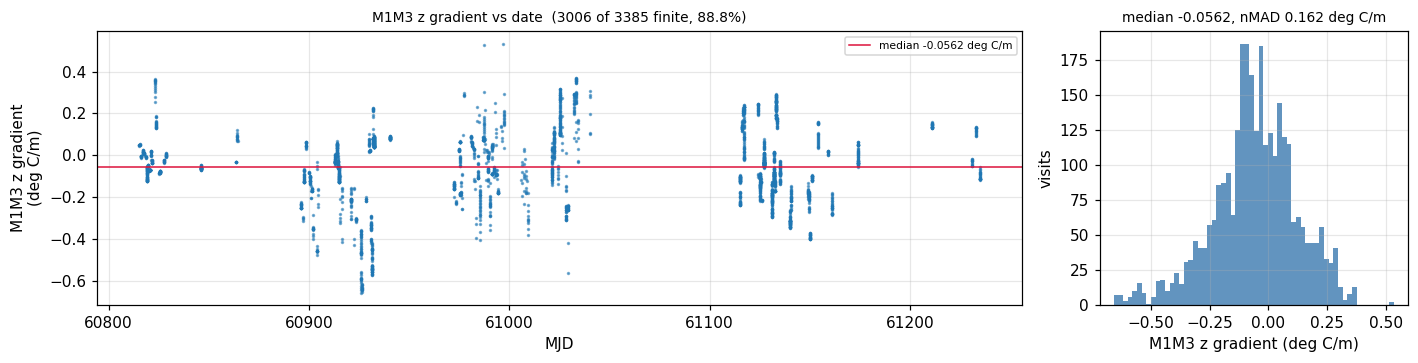

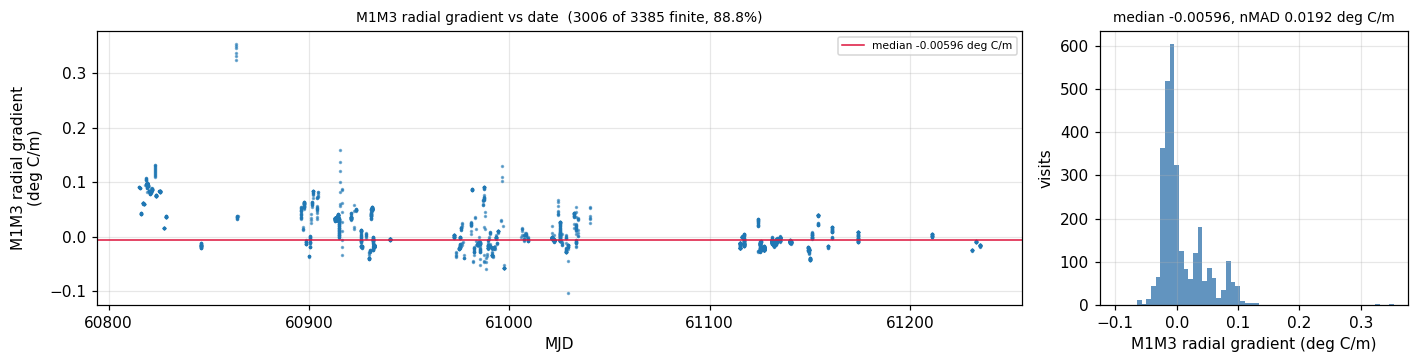

{'n_finite': 3006,
 'median': -0.00595946873524189,
 'nmad': 0.019204703573018476,
 'min': -0.10264751535158365,
 'max': 0.3541165000700588,
 'unit': 'deg C/m'}

In [6]:
group_header('M1M3 thermal gradients', 'deg C per m, from the EFD thermocouple array')
show('z_gradient', 'deg C/m', 'M1M3 z gradient')
show('radial_gradient', 'deg C/m', 'M1M3 radial gradient')

<a id='thermal-air'></a>
## 7. Thermal — air and structure temperatures

Environmental Sensing System (ESS) air temperatures from the Consolidated Database
(ConsDB), their derived differences, and the Telescope Mount Assembly (TMA) truss.
`tma_truss_temp_pxpy` reads lower than the rest because that sensor was deployed part-way
through commissioning.

air and structure temperatures  --  deg C, ConsDB transformed EFD


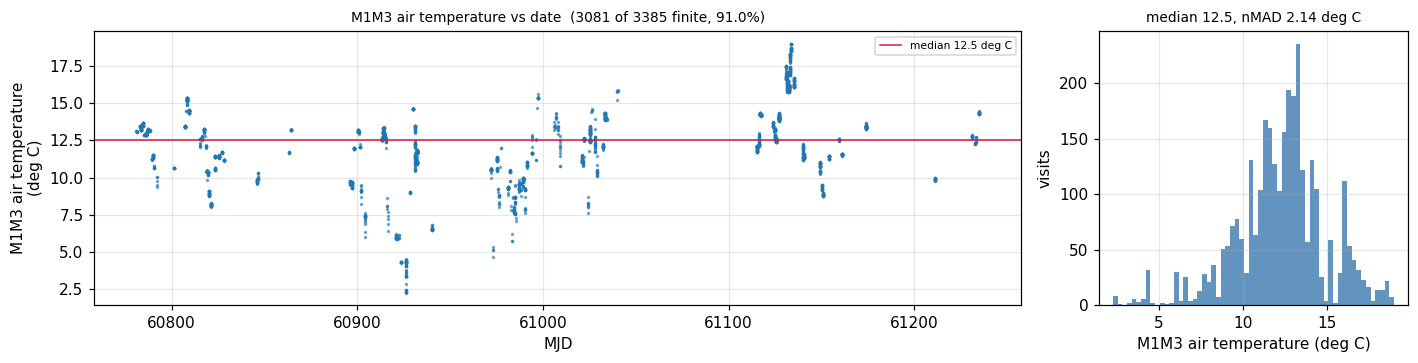

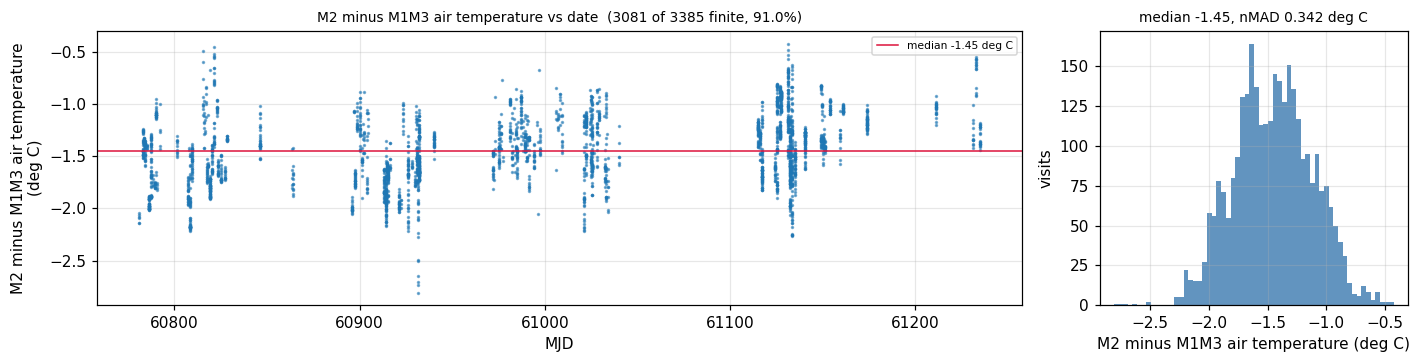

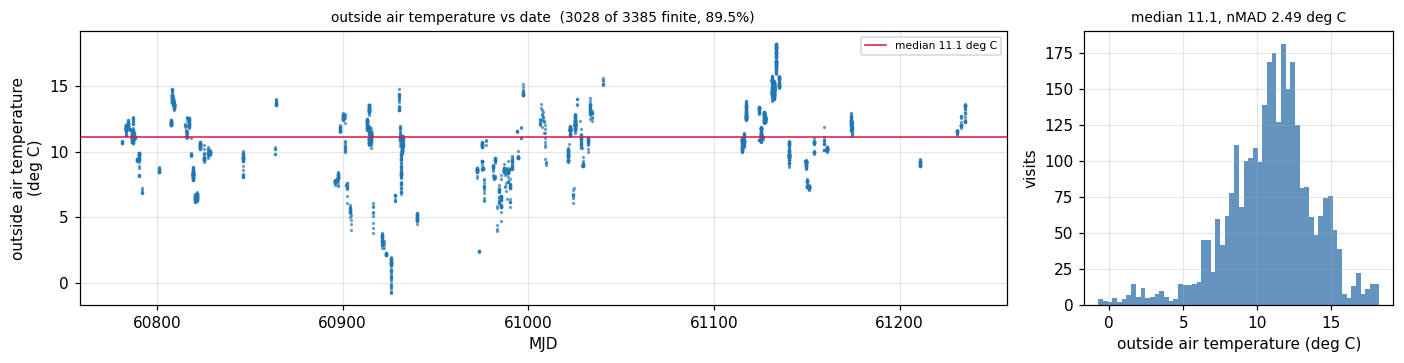

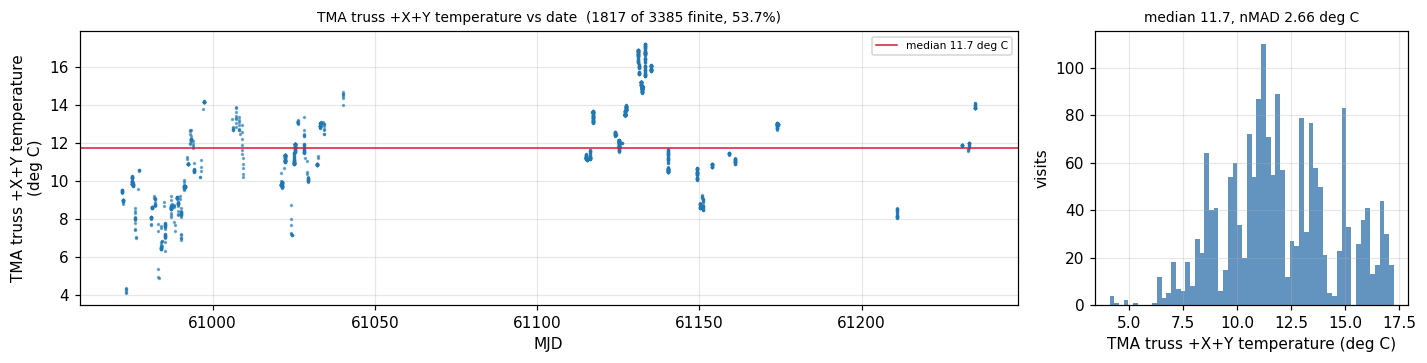

{'n_finite': 1817,
 'median': 11.722999919544566,
 'nmad': 2.656114754746178,
 'min': 4.096527273004705,
 'max': 17.25990851720174,
 'unit': 'deg C'}

In [7]:
group_header('air and structure temperatures', 'deg C, ConsDB transformed EFD')
show('m1m3_air_temp', 'deg C', 'M1M3 air temperature')
show('m2_delta_t', 'deg C', 'M2 minus M1M3 air temperature')
show('outside_temp', 'deg C', 'outside air temperature')
show('tma_truss_temp_pxpy', 'deg C', 'TMA truss +X+Y temperature')

<a id='camera'></a>
## 8. Camera body temperatures

From the camera utility-trunk housekeeping topic in the EFD, which is a separate InfluxDB
database from the main one. `cam_AverageTemp` is the single most useful aggregate; the L1
lens temperature is shown as an example of an individual structural sensor.

camera body  --  deg C, EFD lsst.MTCamera.utiltrunk_body


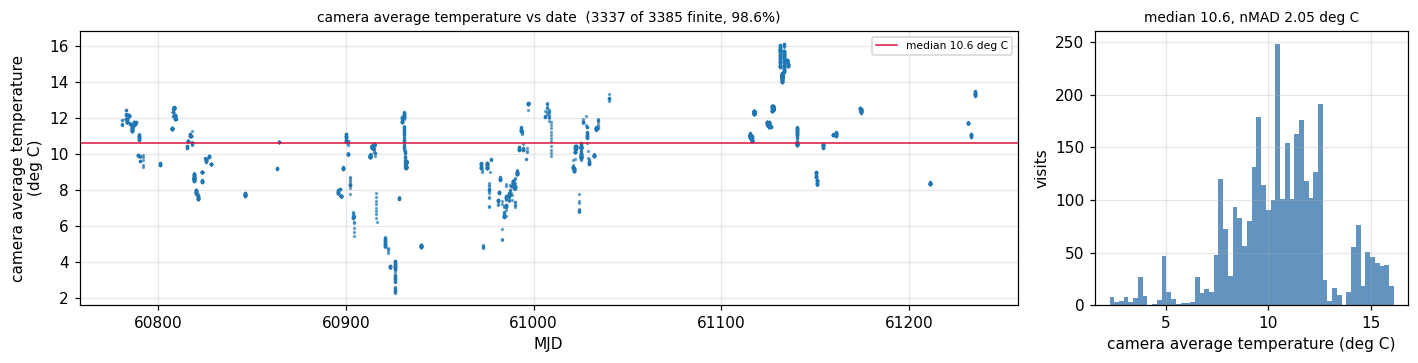

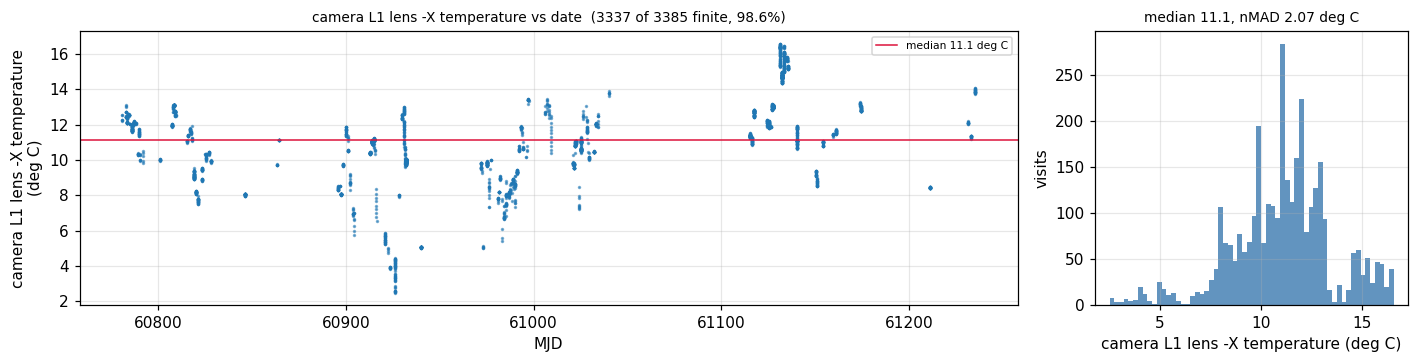

{'n_finite': 3337,
 'median': 11.14085325365206,
 'nmad': 2.0704469621513906,
 'min': 2.4858897742363877,
 'max': 16.596115537848604,
 'unit': 'deg C'}

In [8]:
group_header('camera body', 'deg C, EFD lsst.MTCamera.utiltrunk_body')
show('cam_AverageTemp', 'deg C', 'camera average temperature')
show('cam_L1XMinusTemp', 'deg C', 'camera L1 lens -X temperature')

<a id='wind'></a>
## 9. Wind and airflow

Dome-inside wind from the sonic anemometer and outside airflow from the weather station,
both from ConsDB. Speeds are in m/s; the outside direction is a compass bearing in
degrees, so its distribution is expected to be multi-modal rather than peaked.

wind and airflow  --  ConsDB salindex110 (inside) and salindex301 (outside)


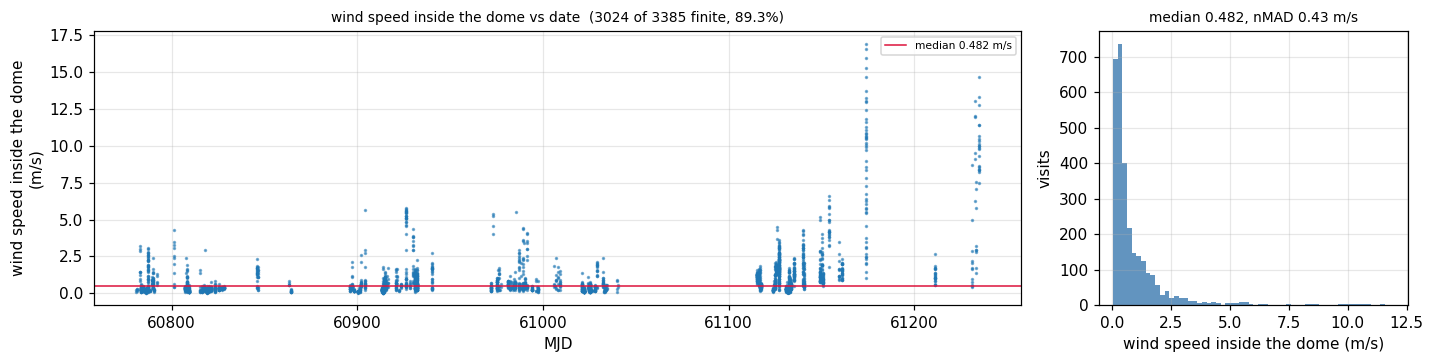

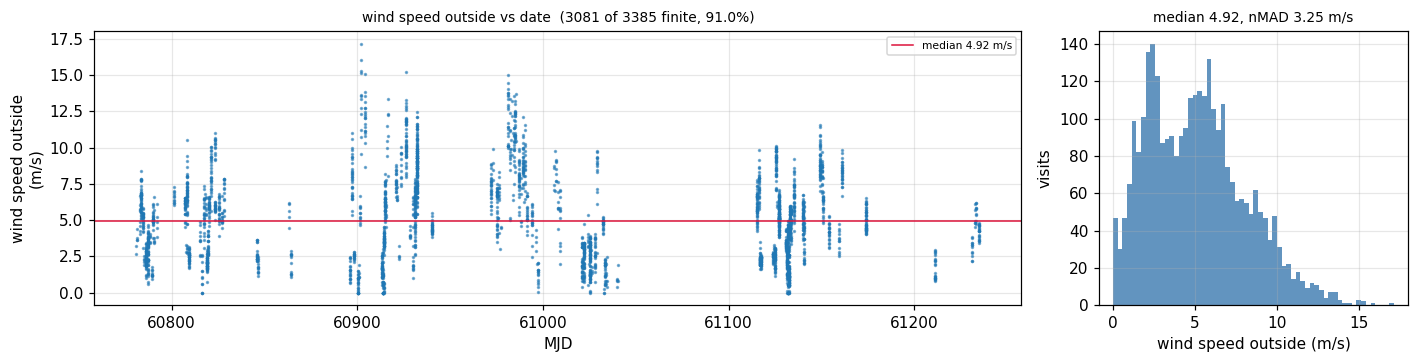

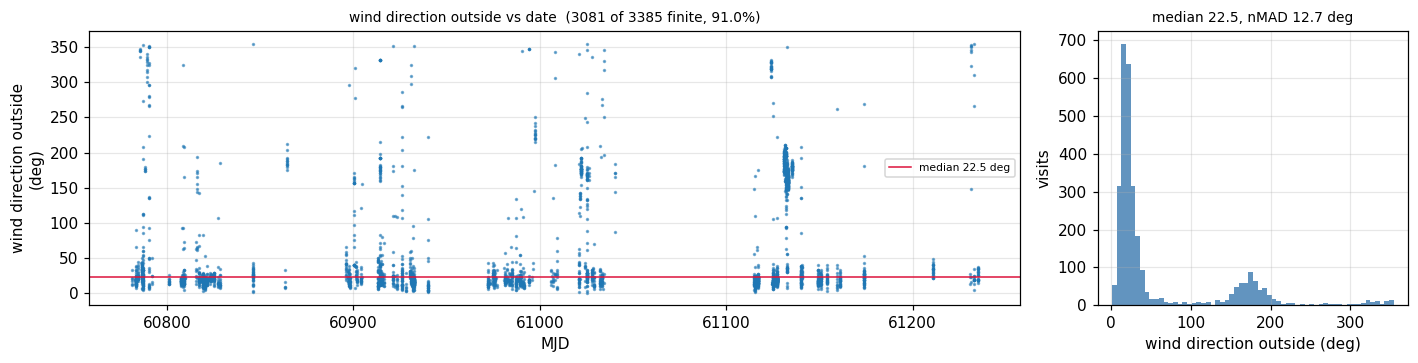

{'n_finite': 3081,
 'median': 22.466765344142914,
 'nmad': 12.677919118916988,
 'min': 0.6670833341777325,
 'max': 355.0292053222656,
 'unit': 'deg'}

In [9]:
group_header('wind and airflow', 'ConsDB salindex110 (inside) and salindex301 (outside)')
show('wind_speed_inside', 'm/s', 'wind speed inside the dome', clip_pct=99.5)
show('wind_speed_outside', 'm/s', 'wind speed outside')
show('wind_dir_outside', 'deg', 'wind direction outside')

<a id='dof'></a>
## 10. Commanded degrees of freedom — Trim and Tweak

**Trim** is the accumulated per-degree-of-freedom (DOF) offset that the Active Optics
System (AOS) has applied, read from the EFD by time because the ConsDB transform does not
populate it for FAM exposures. **Tweak** is the per-iteration correction, derived by
differencing consecutive Trim values: it is 0.0 where the loop applied no new correction,
so its distribution is strongly peaked at zero by construction.

DOF 0 is the M2 hexapod dz and DOF 5 the camera hexapod dz, both in µm.

Trim  --  accumulated DOF offset, EFD MTAOS.logevent_degreeOfFreedom


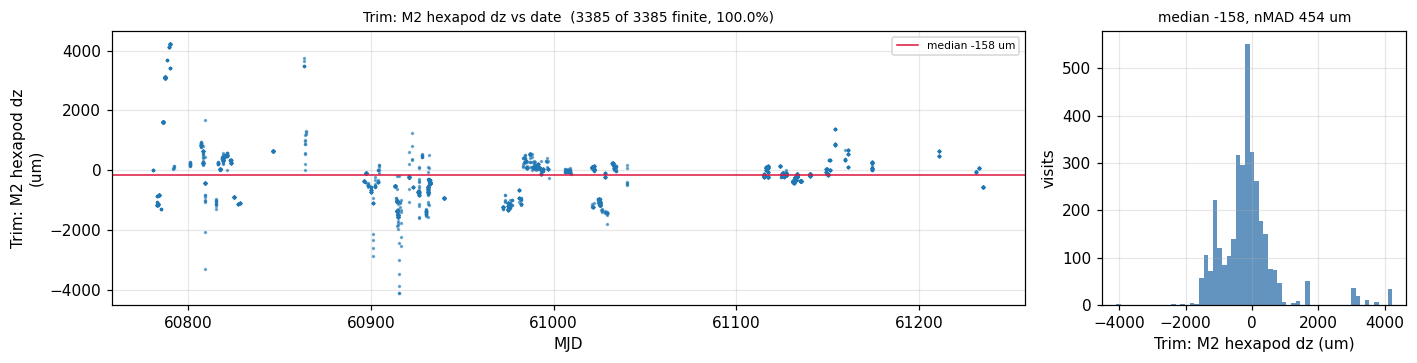

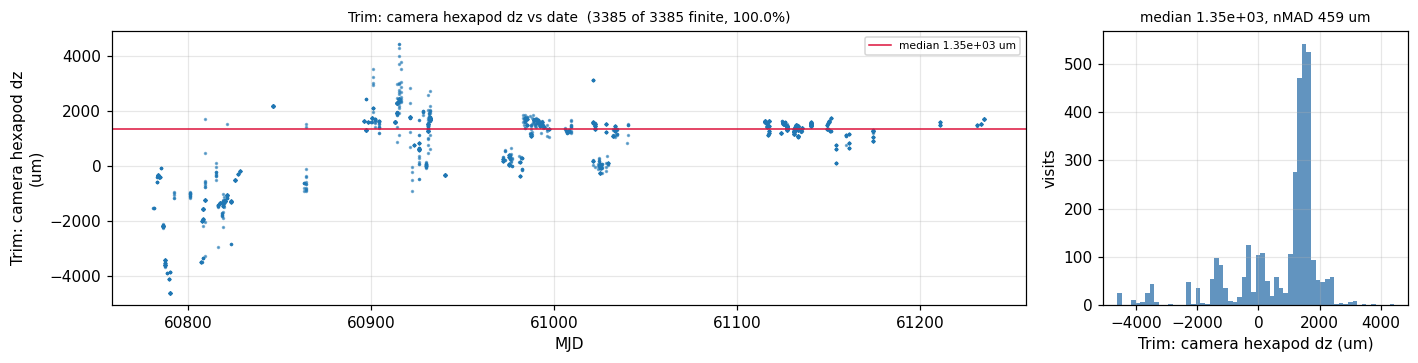

Tweak  --  per-iteration correction, derived by differencing Trim


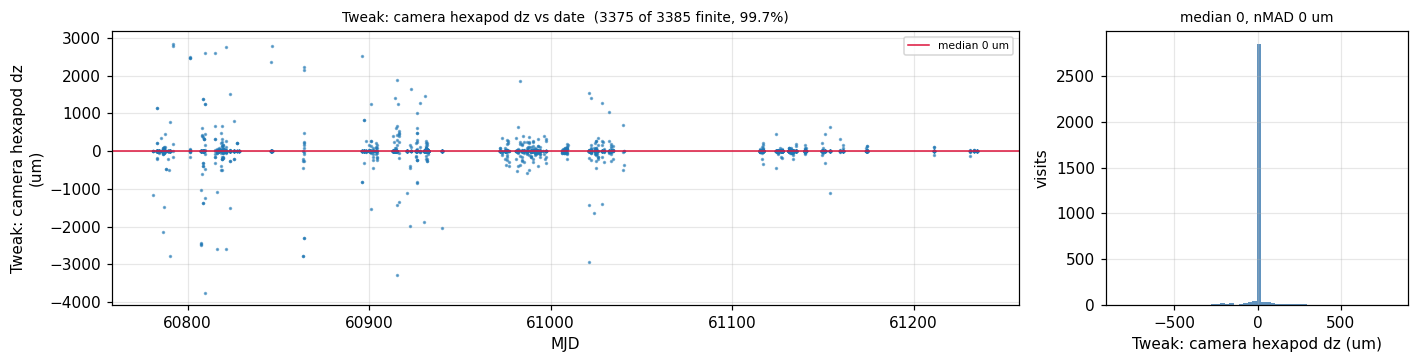


Tweak dof5: 3375 of 3385 known; 653 non-zero corrections, 2722 with none applied


In [10]:
group_header('Trim', 'accumulated DOF offset, EFD MTAOS.logevent_degreeOfFreedom')
show('dof0', 'um', 'Trim: M2 hexapod dz')
show('dof5', 'um', 'Trim: camera hexapod dz')

group_header('Tweak', 'per-iteration correction, derived by differencing Trim')
show('tweak_dof5', 'um', 'Tweak: camera hexapod dz', clip_pct=99.0)

# How often does the loop actually step? Zero means "loop ran, no new correction".
w = df['tweak_dof5'].to_numpy(dtype=float, na_value=np.nan)
fin = np.isfinite(w)
print(f'\nTweak dof5: {int(fin.sum())} of {len(w)} known; '
      f'{int((fin & (w != 0)).sum())} non-zero corrections, '
      f'{int((fin & (w == 0)).sum())} with none applied')

<a id='lut'></a>
## 11. Mirror look-up-table forces

Axial forces the mirror look-up tables (LUT) applied, from ConsDB: 156 M1M3 elevation
actuators and 72 M2 gravity actuators. One actuator from each is shown; these vary
primarily with elevation, so the time history mostly reflects the observing schedule.

mirror LUT axial forces  --  N, ConsDB applied-force properties


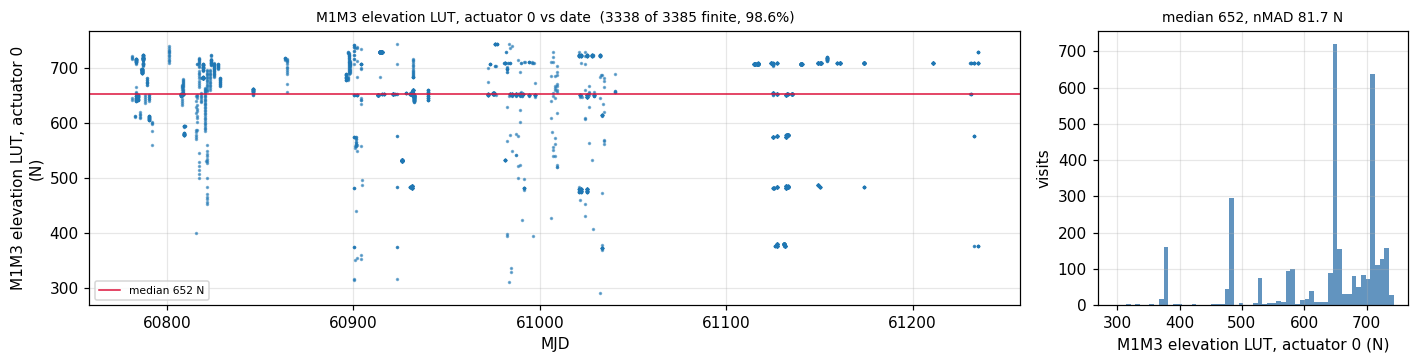

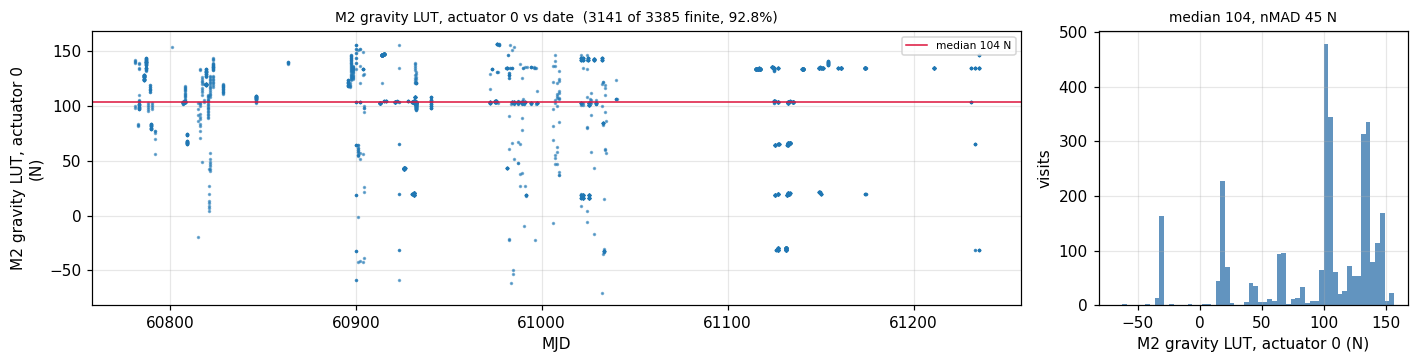

{'n_finite': 3141,
 'median': 103.79425806451611,
 'nmad': 45.0444010258064,
 'min': -70.32204838709677,
 'max': 156.74009677419355,
 'unit': 'N'}

In [11]:
group_header('mirror LUT axial forces', 'N, ConsDB applied-force properties')
show('m1m3elev_0', 'N', 'M1M3 elevation LUT, actuator 0')
show('m2grav_0', 'N', 'M2 gravity LUT, actuator 0')

<a id='pointing'></a>
## 12. Pointing and image quality

Context for everything above. Altitude is stored in radians and converted here; the donut
blur is the per-visit median.

pointing and image quality


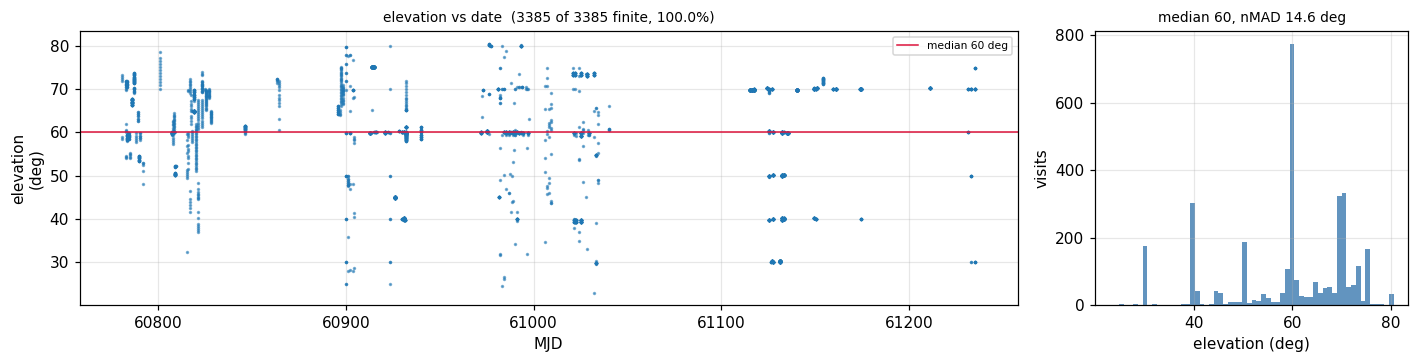

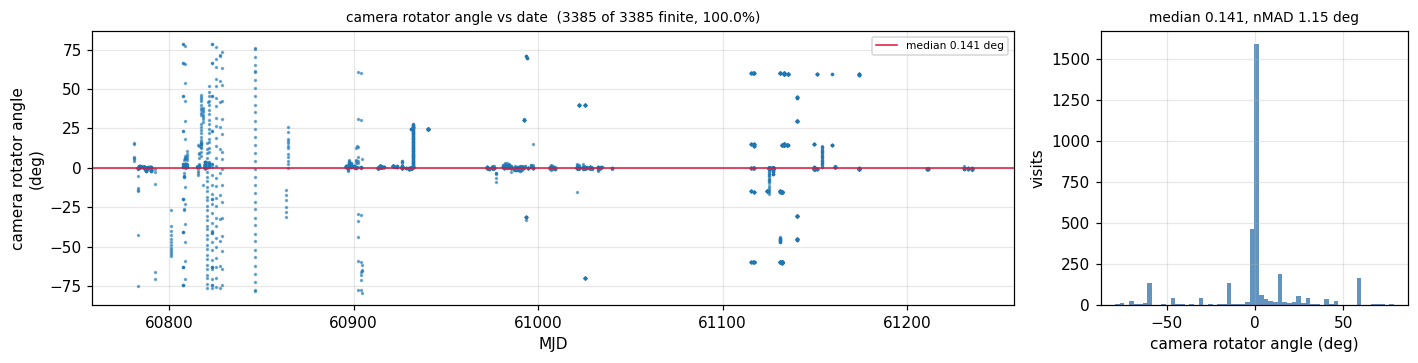

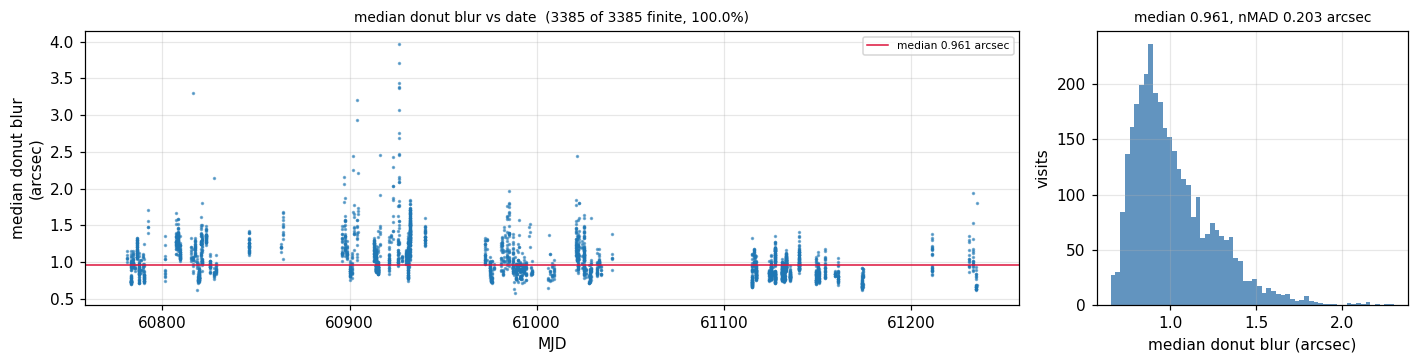

In [12]:
group_header('pointing and image quality')
show('alt', 'deg', 'elevation', transform=alt_to_deg)
show('rotator_angle', 'deg', 'camera rotator angle')
show('median_blur_arcsec', 'arcsec', 'median donut blur', clip_pct=99.5)

if _pdf is not None:
    _pdf.close()
    print('wrote fam_processing/telemetry_history.pdf')